In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image


In [2]:
# # Cần cài đặt nếu chưa có
# # !pip install numpy scipy opencv-python matplotlib

# import numpy as np
# import cv2
# import matplotlib.pyplot as plt
# from scipy.ndimage import median_filter

# def preprocess_ultrasound(img,
#                           speckle_kernel=3,
#                           shadow_window_ratio=0.2,
#                           shadow_threshold_factor=0.7,
#                           gain_slope=1.2,
#                           gain_offset=0.8):
#     """
#     Tiền xử lý ảnh siêu âm với 3 bước:
#     1. Giảm nhiễu speckle → median filter
#     2. Xử lý bóng âm → phát hiện cục bộ + nội suy dọc (Abdel-Dayem & El-Sakka, ICIP 2009)
#     3. Chuẩn hóa gain theo độ sâu → mô phỏng TGC (dù ảnh có thể đã được TGC, vẫn giữ để minh họa)

#     Trả về ảnh sau từng bước để trực quan hóa.
#     """
#     img_float = img.astype(np.float32)

#     # === Bước 1: Giảm nhiễu speckle ===
#     img_denoised = median_filter(img_float, size=speckle_kernel)

#     # === Bước 2: Xử lý bóng âm ===
#     h, w = img_denoised.shape
#     window_size = max(5, int(h * shadow_window_ratio))
#     if window_size % 2 == 0:
#         window_size += 1

#     img_shadow_suppressed = img_denoised.copy()
#     shadow_mask_full = np.zeros((h, w), dtype=bool)

#     for j in range(w):
#         col = img_denoised[:, j]
#         shadow_mask = np.zeros(h, dtype=bool)

#         # Phát hiện bóng cục bộ theo cột
#         for i in range(h):
#             half = window_size // 2
#             start = max(0, i - half)
#             end = min(h, i + half + 1)
#             local_patch = col[start:end]
#             local_mean = np.mean(local_patch)
#             local_std = np.std(local_patch) + 1e-6
#             if col[i] < local_mean - shadow_threshold_factor * local_std:
#                 shadow_mask[i] = True

#         shadow_mask_full[:, j] = shadow_mask

#         # Nội suy dọc
#         for i in range(h):
#             if shadow_mask[i]:
#                 above = below = None
#                 for k in range(i - 1, -1, -1):
#                     if not shadow_mask[k]:
#                         above = col[k]
#                         break
#                 for k in range(i + 1, h):
#                     if not shadow_mask[k]:
#                         below = col[k]
#                         break
#                 if above is not None and below is not None:
#                     img_shadow_suppressed[i, j] = (above + below) / 2.0
#                 elif above is not None:
#                     img_shadow_suppressed[i, j] = above
#                 elif below is not None:
#                     img_shadow_suppressed[i, j] = below

#     # === Bước 3: Gain normalization theo độ sâu (TGC mô phỏng) ===
#     img_gain = np.zeros_like(img_shadow_suppressed)
#     for i in range(h):
#         depth = i / max(h - 1, 1)
#         gain = gain_slope * depth + gain_offset
#         img_gain[i, :] = img_shadow_suppressed[i, :] * gain

#     # Chuẩn hóa ảnh cuối về [0, 255]
#     img_gain_norm = img_gain - img_gain.min()
#     if img_gain_norm.max() > 0:
#         img_gain_norm = img_gain_norm / img_gain_norm.max()
#     img_final = (img_gain_norm * 255).astype(np.uint8)

#     # Trả về ảnh sau từng bước (đã chuẩn hóa về uint8 để hiển thị)
#     img1 = np.clip(img_denoised, 0, 255).astype(np.uint8)
#     img2 = np.clip(img_shadow_suppressed, 0, 255).astype(np.uint8)
#     img3 = img_final

#     return img1, img2, img3

# # --- Thử nghiệm ---
# img = cv2.imread('/kaggle/input/harvard-knee-ultrasound-dataset/imageArchive.11/23101853-8d93-11ee-8081-0a580a5f5f6a_11.png', cv2.IMREAD_GRAYSCALE)
# if img is None:
#     h, w = 256, 256
#     xv, yv = np.meshgrid(np.linspace(0, 1, w), np.linspace(0, 1, h))
#     img = (xv * 200 + 30 + np.random.randn(h, w) * 10).astype(np.uint8)

# # Áp dụng tiền xử lý
# denoised, shadow_suppressed, final = preprocess_ultrasound(
#     img,
#     speckle_kernel=3,
#     shadow_window_ratio=0.2,
#     shadow_threshold_factor=0.7,
#     gain_slope=1.2,
#     gain_offset=0.8
# )

# # Hiển thị kết quả
# plt.figure(figsize=(15, 4))
# plt.subplot(1, 4, 1)
# plt.title('Original')
# plt.imshow(img, cmap='gray')
# plt.axis('off')

# plt.subplot(1, 4, 2)
# plt.title('After Speckle Reduction\n(Median Filter)')
# plt.imshow(denoised, cmap='gray')
# plt.axis('off')

# plt.subplot(1, 4, 3)
# plt.title('After Shadow Suppression\n(Local threshold + vertical interpolation)')
# plt.imshow(shadow_suppressed, cmap='gray')
# plt.axis('off')

# plt.subplot(1, 4, 4)
# plt.title('After Gain Normalization\n(Simulated TGC)')
# plt.imshow(final, cmap='gray')
# plt.axis('off')

# plt.tight_layout()
# plt.show()

In [3]:
def crop_black_border(image, threshold=10, padding=10):
    img_array = np.array(image)
    if len(img_array.shape) == 3:
        img_gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img_array

    _, binary = cv2.threshold(img_gray, threshold, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return image

    # Chọn contour lớn nhất
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)

    # Thêm padding nhỏ
    x = max(0, x - padding)
    y = max(0, y - padding)
    w = min(w + 2*padding, img_gray.shape[1] - x)
    h = min(h + 2*padding, img_gray.shape[0] - y)

    if len(img_array.shape) == 3:
        cropped = img_array[y:y+h, x:x+w, :]
    else:
        cropped = img_array[y:y+h, x:x+w]

    return Image.fromarray(cropped)

## Harvard Dataset DataLoader

In [4]:
# --- 1. CẤU HÌNH BAN ĐẦU ---
DATA_DIR = "/kaggle/input/harvard-knee-ultrasound-dataset/"

# Kích thước ảnh đầu vào cho EfficientNetB0
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 50
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
# THÊM MỚI: Cấu hình cho Gradient Clipping
CLIP_GRAD_MAX_NORM = 0.1

# Chọn thiết bị (GPU nếu có, nếu không thì CPU)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sử dụng thiết bị: {DEVICE}")


Sử dụng thiết bị: cuda


In [5]:
# --- Dataset ---
class KneeUltrasoundDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Đọc ảnh
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"Không thể đọc ảnh: {img_path}")
        
        # Chuyển sang RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Cắt viền đen tự động
        img_pil = Image.fromarray(img_rgb)
        img_cropped = crop_black_border(img_pil)

        # Áp dụng transform (nếu có)
        if self.transform:
            image = self.transform(img_cropped)
        else:
            image = torch.tensor(np.array(img_cropped)).permute(2, 0, 1).float() / 255.0
        
        return image, torch.tensor(label, dtype=torch.long)


In [6]:
def prepare_data(data_dir):
    all_image_paths = []
    all_labels_raw = []

    all_subdirs = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    print(f"Tất cả các thư mục con trong dữ liệu: {sorted(all_subdirs)}")

    # Lọc thư mục hợp lệ
    valid_subdirs = [
        d for d in all_subdirs
        if d.startswith("imageArchive.")
        and d.split('.')[-1].isdigit()
        and d.split('.')[-1] not in ["12", "22", "13", "23"]
    ]

    if not valid_subdirs:
        raise FileNotFoundError(f"Không tìm thấy thư mục hợp lệ trong {data_dir}")

    print(f"\nCác thư mục hợp lệ sau khi lọc: {sorted(valid_subdirs)}")

    # --- ÁNH XẠ MỚI THEO CLASS_NAMES ---
    # CLASS_NAMES = ['sup-up-long', 'med-lat', 'sup-trans-flex', 'post-trans']
    label_mapping = {
        1: 0,  # 11,21 → 'sup-up-long'
        4: 1,  # 14,24 → 'med-lat'
        5: 1,  # 15,25 → 'med-lat'
        6: 2,  # 16,26 → 'sup-trans-flex'
        7: 3   # 17,27 → 'post-trans'
    }

    # --- Duyệt tất cả thư mục và gom dữ liệu ---
    for subdir_name in valid_subdirs:
        label_str = subdir_name.split('.')[-1]
        label_int = int(label_str)
        suffix = label_int % 10

        if suffix not in label_mapping:
            print(f"CẢNH BÁO: Thư mục {subdir_name} có hậu tố {suffix}, không ánh xạ được.")
            continue

        unified_label = label_mapping[suffix]
        subdir_path = os.path.join(data_dir, subdir_name)

        for filename in os.listdir(subdir_path):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_image_paths.append(os.path.join(subdir_path, filename))
                all_labels_raw.append(unified_label)

    labels_array = np.array(all_labels_raw)

    # --- DEBUG ---
    unique_labels_found = np.unique(labels_array)
    print(f"\nCác nhãn duy nhất (sau hợp nhất): {sorted(unique_labels_found)}")
    print(f"Số lượng mẫu mỗi nhãn: {dict(zip(*np.unique(labels_array, return_counts=True)))}")

    NUM_CLASSES = 4
    if unique_labels_found.max() >= NUM_CLASSES:
        raise ValueError(f"Nhãn tối đa ({unique_labels_found.max()}) vượt quá NUM_CLASSES={NUM_CLASSES}")

    # --- Chia train / val / test ---
    # 70% train, 15% val, 15% test
    try:
        # Bước 1: chia train (70%) và temp (30%)
        train_paths, temp_paths, train_labels, temp_labels = train_test_split(
            all_image_paths, labels_array,
            test_size=0.3, random_state=42, stratify=labels_array
        )

        # Bước 2: chia temp thành val (15%) và test (15%)
        val_paths, test_paths, val_labels, test_labels = train_test_split(
            temp_paths, temp_labels,
            test_size=0.5, random_state=42, stratify=temp_labels
        )

    except ValueError as e:
        print(f"\n⚠️ CẢNH BÁO: Lỗi stratify ({e}) — chia không stratify để tránh lỗi lớp nhỏ")
        train_paths, temp_paths, train_labels, temp_labels = train_test_split(
            all_image_paths, labels_array, test_size=0.3, random_state=42
        )
        val_paths, test_paths, val_labels, test_labels = train_test_split(
            temp_paths, temp_labels, test_size=0.5, random_state=42
        )

    # --- In thông tin thống kê ---
    print(f"\nTổng số mẫu: {len(all_image_paths)}")
    print(f"Tập train: {len(train_paths)} mẫu ({len(train_paths)/len(all_image_paths)*100:.1f}%)")
    print(f"Tập val:   {len(val_paths)} mẫu ({len(val_paths)/len(all_image_paths)*100:.1f}%)")
    print(f"Tập test:  {len(test_paths)} mẫu ({len(test_paths)/len(all_image_paths)*100:.1f}%)")

    print(f"\nPhân phối nhãn trong train: {dict(zip(*np.unique(train_labels, return_counts=True)))}")
    print(f"Phân phối nhãn trong val:   {dict(zip(*np.unique(val_labels, return_counts=True)))}")
    print(f"Phân phối nhãn trong test:  {dict(zip(*np.unique(test_labels, return_counts=True)))}")

    return (train_paths, train_labels), (val_paths, val_labels), (test_paths, test_labels)


In [7]:
def resize_with_padding(img, size=IMG_SIZE):
    """Resize ảnh giữ nguyên tỉ lệ, pad 0 (đen) để vừa size."""
    w, h = img.size
    target_w, target_h = size
    scale = min(target_w / w, target_h / h)
    new_w, new_h = int(w * scale), int(h * scale)

    # Resize giữ tỉ lệ
    img = img.resize((new_w, new_h), Image.BILINEAR)

    # Tạo nền đen và paste ảnh vào giữa
    new_img = Image.new("RGB", (target_w, target_h), (0, 0, 0))
    paste_x = (target_w - new_w) // 2
    paste_y = (target_h - new_h) // 2
    new_img.paste(img, (paste_x, paste_y))

    return new_img

In [8]:
# Định nghĩa các phép biến đổi
# Sử dụng chuẩn hóa theo giá trị trung bình và độ lệch chuẩn của ImageNet
data_transforms = {
    'train': transforms.Compose([
        # transforms.ToPILImage(),

        transforms.Lambda(lambda img: resize_with_padding(img, IMG_SIZE)),
        
        # --- CÁC PHÉP TĂNG CƯỜNG DỮ LIỆU MỚI ---
        
        # 1. Thay đổi độ sáng và tương phản
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        
        # 2. Áp dụng làm mờ Gaussian với xác suất 50%
        transforms.RandomApply([
            transforms.GaussianBlur(kernel_size=(3, 5), sigma=(0.1, 1.0))
        ], p=0.5),
        
        # --- CÁC PHÉP TĂNG CƯỜNG DỮ LIỆU CŨ ---
        transforms.RandomHorizontalFlip(p=0.5),
        # transforms.RandomRotation(10),
        transforms.RandomApply([transforms.RandomRotation(10)], p=0.5),
        
        # --- CHUYỂN ĐỔI VÀ CHUẨN HÓA ---
        transforms.ToTensor(), # Chuyển ảnh sang Tensor

        # Chuẩn hóa (luôn đặt ở cuối cùng)
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        # transforms.Normalize([123.675, 116.28, 103.53], [58.395, 57.12, 57.375])
        
    ]),
    
    'val': transforms.Compose([
        # transforms.ToPILImage(),
        transforms.Lambda(lambda img: resize_with_padding(img, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        # transforms.Normalize([123.675, 116.28, 103.53], [58.395, 57.12, 57.375])
        
    ]),
}

try:
    # (train_paths, train_labels), (val_paths, val_labels) = prepare_data(DATA_DIR)
    (train_paths, train_labels), (val_paths, val_labels), (test_paths, test_labels) = prepare_data(DATA_DIR)

    # Tạo các đối tượng Dataset
    train_dataset = KneeUltrasoundDataset(train_paths, train_labels, transform=data_transforms['train'])
    val_dataset = KneeUltrasoundDataset(val_paths, val_labels, transform=data_transforms['val'])
    test_dataset = KneeUltrasoundDataset(test_paths, test_labels, transform=data_transforms['val'])

    # Tạo các đối tượng DataLoader
    train_loader = DataLoader(
        train_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=True, 
        num_workers=4, # Tăng số lượng worker
        pin_memory=True # Bật pin_memory
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=4, 
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset, 
        batch_size=BATCH_SIZE, 
        shuffle=False, 
        num_workers=4, 
        pin_memory=True
    )

    print(f"\nKích thước các tập dữ liệu:")
    print(f"  Tập huấn luyện: {len(train_dataset)}")
    print(f"  Tập kiểm định:  {len(val_dataset)}")
    print(f"  Tập kiểm tra:   {len(test_dataset)}")

except FileNotFoundError as e:
    print(f"\nLỖI: {e}")
    print("Vui lòng kiểm tra và sửa lại biến 'DATA_DIR' ở đầu script.")
    exit()

Tất cả các thư mục con trong dữ liệu: ['imageArchive.11', 'imageArchive.12', 'imageArchive.13', 'imageArchive.14', 'imageArchive.15', 'imageArchive.16', 'imageArchive.17', 'imageArchive.21', 'imageArchive.22', 'imageArchive.23', 'imageArchive.24', 'imageArchive.25', 'imageArchive.26', 'imageArchive.27']

Các thư mục hợp lệ sau khi lọc: ['imageArchive.11', 'imageArchive.14', 'imageArchive.15', 'imageArchive.16', 'imageArchive.17', 'imageArchive.21', 'imageArchive.24', 'imageArchive.25', 'imageArchive.26', 'imageArchive.27']

Các nhãn duy nhất (sau hợp nhất): [0, 1, 2, 3]
Số lượng mẫu mỗi nhãn: {0: 1733, 1: 3466, 2: 1730, 3: 1669}

Tổng số mẫu: 8598
Tập train: 6018 mẫu (70.0%)
Tập val:   1290 mẫu (15.0%)
Tập test:  1290 mẫu (15.0%)

Phân phối nhãn trong train: {0: 1213, 1: 2426, 2: 1211, 3: 1168}
Phân phối nhãn trong val:   {0: 260, 1: 520, 2: 259, 3: 251}
Phân phối nhãn trong test:  {0: 260, 1: 520, 2: 260, 3: 250}

Kích thước các tập dữ liệu:
  Tập huấn luyện: 6018
  Tập kiểm định:  12


--- 6. TRỰC QUAN HÓA MẪU DỮ LIỆU TỪ TẬP HUẤN LUYỆN ---


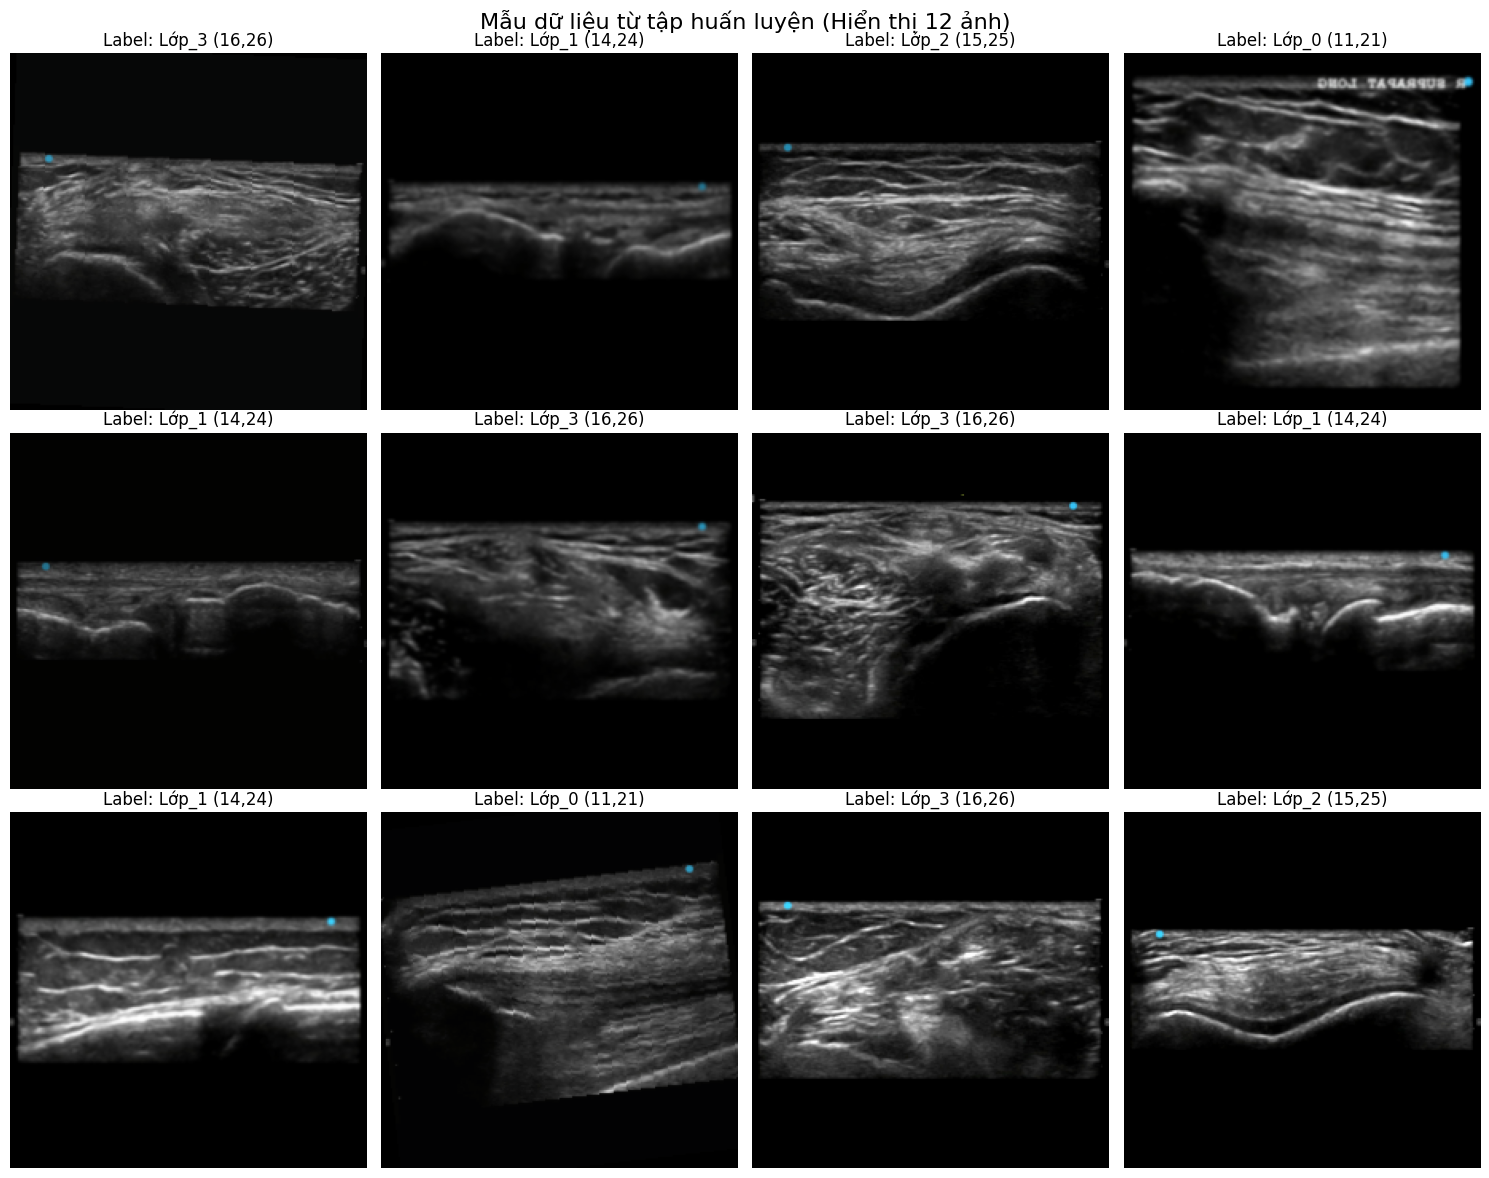

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# --- 6. TRỰC QUAN HÓA DỮ LIỆU ---
print("\n--- 6. TRỰC QUAN HÓA MẪU DỮ LIỆU TỪ TẬP HUẤN LUYỆN ---")

def visualize_dataset_samples(dataset, num_samples=8, class_names=None):
    """
    Hiển thị một số mẫu ảnh từ dataset.

    Args:
        dataset: Dataset object (e.g., train_dataset)
        num_samples (int): Số lượng mẫu ảnh muốn hiển thị.
        class_names (list, optional): Danh sách tên lớp nếu có. Nếu không, sẽ hiển thị nhãn số.
    """
    if num_samples > len(dataset):
        print(f"Chỉ có {len(dataset)} mẫu trong dataset, sẽ hiển thị tất cả.")
        num_samples = len(dataset)

    # Tạo subplot
    cols = 4  # Số cột trong lưới hình ảnh
    rows = (num_samples + cols - 1) // cols  # Tính số hàng cần thiết
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    fig.suptitle(f'Mẫu dữ liệu từ tập huấn luyện (Hiển thị {num_samples} ảnh)', fontsize=16)

    # Đảm bảo axes là mảng 1D để dễ dàng lặp
    if rows == 1:
        axes = axes.ravel()
    else:
        axes = axes.flatten()

    for i in range(num_samples):
        # Lấy mẫu ngẫu nhiên
        idx = np.random.randint(0, len(dataset))
        image, label = dataset[idx] # image là tensor sau transform

        # Chuyển tensor về numpy array và chuyển đổi trục (C, H, W) -> (H, W, C)
        img_np = image.permute(1, 2, 0).numpy() # (Height, Width, Channels)

        # Huỷ chuẩn hóa để hiển thị ảnh có màu sắc đúng (nếu dùng ImageNet normalization)
        # Các giá trị mean và std từ transforms.Normalize
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1) # Đảm bảo giá trị nằm trong [0, 1]

        # Vẽ ảnh
        axes[i].imshow(img_np)
        if class_names:
            axes[i].set_title(f'Label: {class_names[label]}')
        else:
            axes[i].set_title(f'Label: {label}')
        axes[i].axis('off') # Tắt trục

    # Ẩn các subplot trống nếu có
    for j in range(num_samples, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Gọi hàm để hiển thị mẫu từ train_dataset
# Bạn có thể định nghĩa class_names nếu muốn hiển thị tên lớp thay vì số
# Ví dụ: class_names = ['Class_0', 'Class_1', 'Class_2', 'Class_3', 'Class_4']
# Nếu không, chỉ nhãn số sẽ được hiển thị
# class_names = ['Lớp 1 (11,21)', 'Lớp 2 (14,24)', 'Lớp 3 (15,25)', 'Lớp 4 (16,26)', 'Lớp 5 (17,27)'] # Theo logic cũ
# Nếu bạn đã thay đổi logic hợp nhất, hãy điều chỉnh cho phù hợp.
# Với logic hiện tại: 0:11/21, 1:14/24, 2:15/25, 3:16/26, 4:17/27
class_names = [f'Lớp_{i} ({["11,21", "14,24", "15,25", "16,26", "17,27"][i]})' for i in range(NUM_CLASSES)]

visualize_dataset_samples(train_dataset, num_samples=12, class_names=class_names)


## E Hospital DataLoader

In [10]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import numpy as np
import cv2
import random

# --- CẤU HÌNH ---
DATA_DIRS = [
    "/kaggle/input/knee-angle-ehospital/classify-bandicam/classify-bandicam",
    "/kaggle/input/knee-angle-ehospital/classify-data-16.10-20251022T032049Z-1-001/classify-data-16.10"
]

CLASS_NAMES = ['sup-up-long', 'med-lat', 'sup-trans-flex', 'post-trans']
IMG_SIZE = (224, 224)
SEED = 42  # để chia ngẫu nhiên có thể tái lập
torch.manual_seed(SEED)
random.seed(SEED)

# --- HÀM CẮT VIỀN ĐEN ---
def crop_black_border(image, threshold=10, padding=10):
    img_array = np.array(image)
    # if len(img_array.shape) == 3:
    #     img_gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    # else:
    #     img_gray = img_array

    # _, binary = cv2.threshold(img_gray, threshold, 255, cv2.THRESH_BINARY)
    # contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    # if not contours:
    #     return image

    # largest_contour = max(contours, key=cv2.contourArea)
    # x, y, w, h = cv2.boundingRect(largest_contour)

    # x = max(0, x - padding)
    # y = max(0, y - padding)
    # w = min(w + 2 * padding, img_gray.shape[1] - x)
    # h = min(h + 2 * padding, img_gray.shape[0] - y)

    # cropped = img_array[y:y + h, x:x + w]
    # return Image.fromarray(cropped)
    return Image.fromarray(img_array)


# --- TRANSFORM ---
data_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


# --- DATASET ---
class NewKneeUltrasoundDataset(Dataset):
    def __init__(self, data_dirs, class_names, transform=None):
        self.class_names = class_names
        self.transform = transform
        self.image_paths = []
        self.labels = []

        print("Đang tải dữ liệu từ các thư mục:")
        for data_dir in data_dirs:
            if not os.path.isdir(data_dir):
                print(f"  ⚠️  Bỏ qua vì không tồn tại: {data_dir}")
                continue
            print(f"  ✅ {data_dir}")

            # Tải dữ liệu từ từng class
            for label_idx, class_name in enumerate(class_names):
                class_dir = os.path.join(data_dir, class_name)
                if not os.path.isdir(class_dir):
                    print(f"    ⚠️  Không có thư mục lớp '{class_name}' trong {data_dir}")
                    continue

                for filename in os.listdir(class_dir):
                    if filename.lower().endswith(('.jpg', '.png', '.jpeg')):
                        self.image_paths.append(os.path.join(class_dir, filename))
                        self.labels.append(label_idx)

        print(f"Tổng số ảnh tải được: {len(self.image_paths)}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        # Đọc ảnh
        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f"Không thể đọc ảnh: {img_path}")

        # BGR -> RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Cắt viền đen tự động
        img_pil = Image.fromarray(img_rgb)
        img_cropped = crop_black_border(img_pil)

        # Transform
        if self.transform:
            image = self.transform(img_cropped)
        else:
            image = torch.tensor(np.array(img_cropped)).permute(2, 0, 1).float() / 255.0

        return image, torch.tensor(label, dtype=torch.long)


# --- KHỞI TẠO DATASET GỐC ---
full_dataset = NewKneeUltrasoundDataset(
    data_dirs=DATA_DIRS,
    class_names=CLASS_NAMES,
    transform=data_transform
)

# # --- CHIA DỮ LIỆU ---
# total_size = len(full_dataset)
# train_size = int(0.7 * total_size)
# val_size = int(0.15 * total_size)
# test_size = total_size - train_size - val_size

# E_train_dataset, E_val_dataset, E_test_dataset = random_split(
#     full_dataset, [train_size, val_size, test_size],
#     generator=torch.Generator().manual_seed(SEED)
# )

# print(f"Tổng: {total_size}, Train: {len(E_train_dataset)}, Val: {len(E_val_dataset)}, Test: {len(E_test_dataset)}")


# E_train_loader = DataLoader(E_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
# E_val_loader   = DataLoader(E_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
# E_test_loader  = DataLoader(E_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Đang tải dữ liệu từ các thư mục:
  ✅ /kaggle/input/knee-angle-ehospital/classify-bandicam/classify-bandicam
  ✅ /kaggle/input/knee-angle-ehospital/classify-data-16.10-20251022T032049Z-1-001/classify-data-16.10
Tổng số ảnh tải được: 185



--- 6. TRỰC QUAN HÓA MẪU DỮ LIỆU TỪ TẬP HUẤN LUYỆN ---


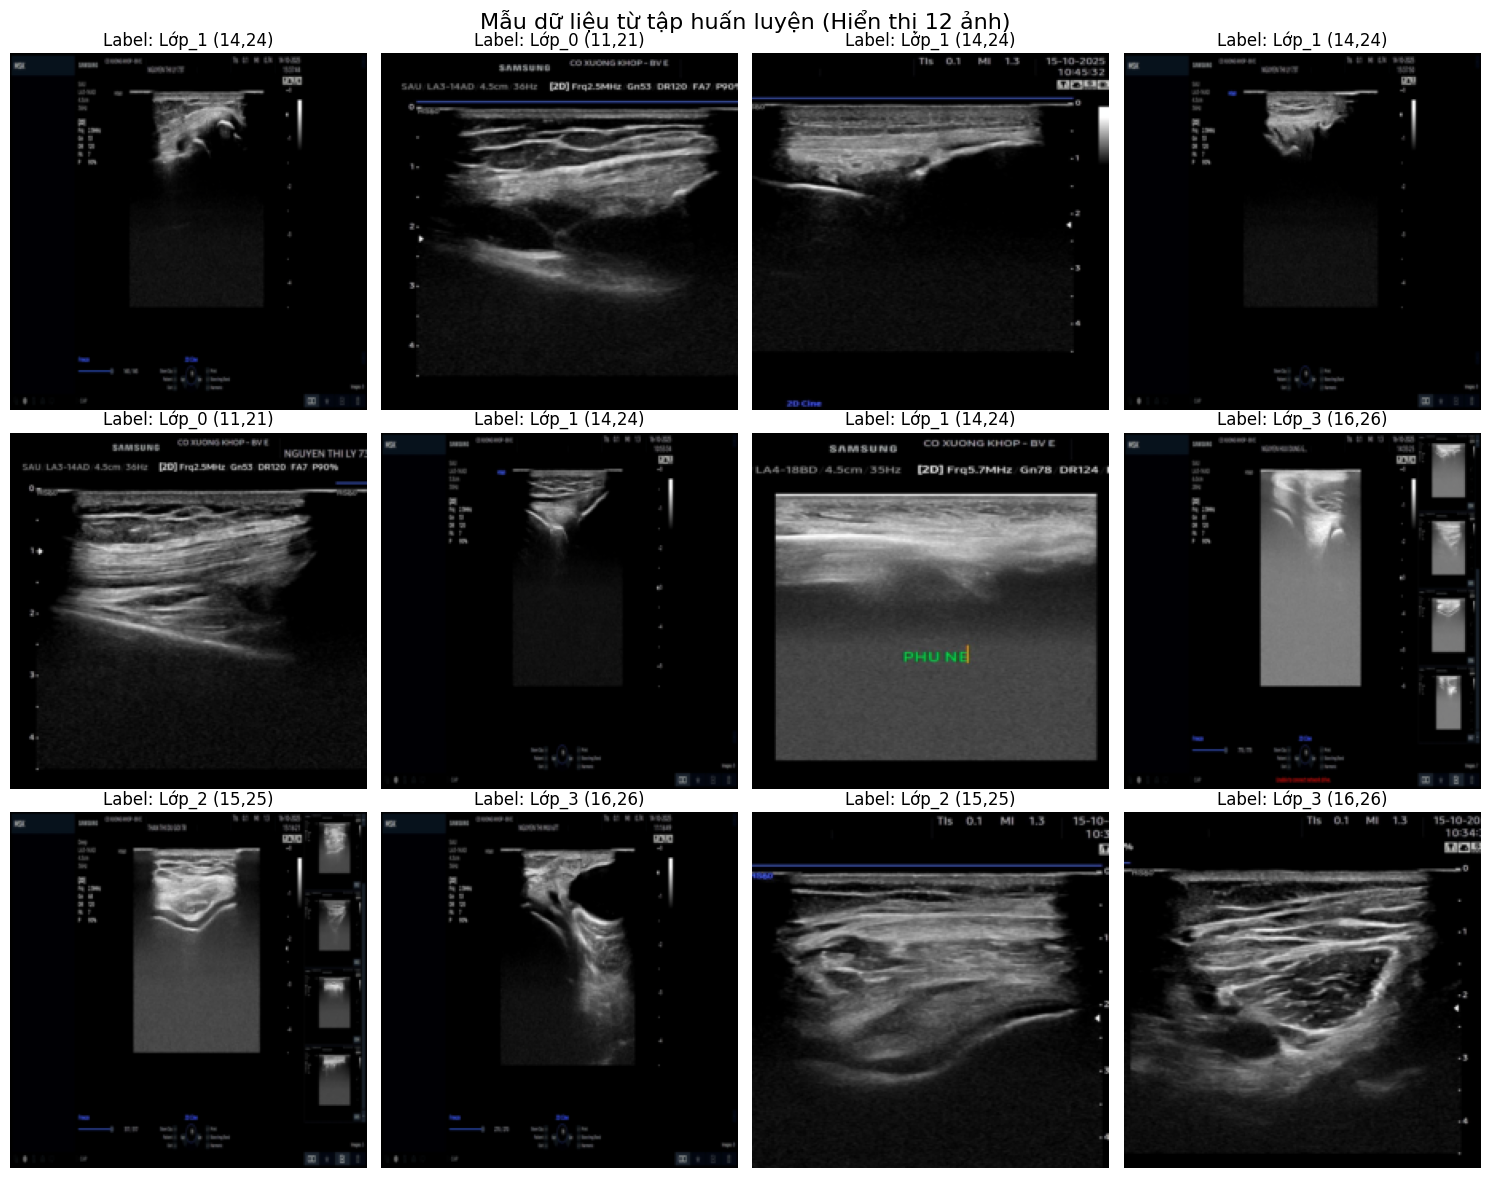

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

NUM_CLASSES = 4

# --- 6. TRỰC QUAN HÓA DỮ LIỆU ---
print("\n--- 6. TRỰC QUAN HÓA MẪU DỮ LIỆU TỪ TẬP HUẤN LUYỆN ---")

def visualize_dataset_samples(dataset, num_samples=8, class_names=None):
    """
    Hiển thị một số mẫu ảnh từ dataset.

    Args:
        dataset: Dataset object (e.g., train_dataset)
        num_samples (int): Số lượng mẫu ảnh muốn hiển thị.
        class_names (list, optional): Danh sách tên lớp nếu có. Nếu không, sẽ hiển thị nhãn số.
    """
    if num_samples > len(dataset):
        print(f"Chỉ có {len(dataset)} mẫu trong dataset, sẽ hiển thị tất cả.")
        num_samples = len(dataset)

    # Tạo subplot
    cols = 4  # Số cột trong lưới hình ảnh
    rows = (num_samples + cols - 1) // cols  # Tính số hàng cần thiết
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    fig.suptitle(f'Mẫu dữ liệu từ tập huấn luyện (Hiển thị {num_samples} ảnh)', fontsize=16)

    # Đảm bảo axes là mảng 1D để dễ dàng lặp
    if rows == 1:
        axes = axes.ravel()
    else:
        axes = axes.flatten()

    for i in range(num_samples):
        # Lấy mẫu ngẫu nhiên
        idx = np.random.randint(0, len(dataset))
        image, label = dataset[idx] # image là tensor sau transform

        # Chuyển tensor về numpy array và chuyển đổi trục (C, H, W) -> (H, W, C)
        img_np = image.permute(1, 2, 0).numpy() # (Height, Width, Channels)

        # Huỷ chuẩn hóa để hiển thị ảnh có màu sắc đúng (nếu dùng ImageNet normalization)
        # Các giá trị mean và std từ transforms.Normalize
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1) # Đảm bảo giá trị nằm trong [0, 1]

        # Vẽ ảnh
        axes[i].imshow(img_np)
        if class_names:
            axes[i].set_title(f'Label: {class_names[label]}')
        else:
            axes[i].set_title(f'Label: {label}')
        axes[i].axis('off') # Tắt trục

    # Ẩn các subplot trống nếu có
    for j in range(num_samples, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Gọi hàm để hiển thị mẫu từ train_dataset
# Bạn có thể định nghĩa class_names nếu muốn hiển thị tên lớp thay vì số
# Ví dụ: class_names = ['Class_0', 'Class_1', 'Class_2', 'Class_3', 'Class_4']
# Nếu không, chỉ nhãn số sẽ được hiển thị
# class_names = ['Lớp 1 (11,21)', 'Lớp 2 (14,24)', 'Lớp 3 (15,25)', 'Lớp 4 (16,26)', 'Lớp 5 (17,27)'] # Theo logic cũ
# Nếu bạn đã thay đổi logic hợp nhất, hãy điều chỉnh cho phù hợp.
# Với logic hiện tại: 0:11/21, 1:14/24, 2:15/25, 3:16/26, 4:17/27
class_names = [f'Lớp_{i} ({["11,21", "14,24", "15,25", "16,26", "17,27"][i]})' for i in range(NUM_CLASSES)]

visualize_dataset_samples(full_dataset, num_samples=12, class_names=class_names)
# visualize_dataset_samples(E_train_dataset, num_samples=12, class_names=class_names)

## Training

In [12]:
# --- 1. CẤU HÌNH BAN ĐẦU ---
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 50
LEARNING_RATE = 2e-4
WEIGHT_DECAY = 1e-4
# THÊM MỚI: Cấu hình cho Gradient Clipping
CLIP_GRAD_MAX_NORM = 0.1

# Chọn thiết bị (GPU nếu có, nếu không thì CPU)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sử dụng thiết bị: {DEVICE}")

Sử dụng thiết bị: cuda


### Loss Function

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class FocalLoss(nn.Module):
    def __init__(self, gamma=2, alpha=None, reduction='mean', task_type='binary', num_classes=None):
        """
        Unified Focal Loss class for binary, multi-class, and multi-label classification tasks.
        :param gamma: Focusing parameter, controls the strength of the modulating factor (1 - p_t)^gamma
        :param alpha: Balancing factor, can be a scalar or a tensor for class-wise weights. If None, no class balancing is used.
        :param reduction: Specifies the reduction method: 'none' | 'mean' | 'sum'
        :param task_type: Specifies the type of task: 'binary', 'multi-class', or 'multi-label'
        :param num_classes: Number of classes (only required for multi-class classification)
        """
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.reduction = reduction
        self.task_type = task_type
        self.num_classes = num_classes

        # Handle alpha for class balancing in multi-class tasks
        if task_type == 'multi-class' and alpha is not None and isinstance(alpha, (list, torch.Tensor)):
            assert num_classes is not None, "num_classes must be specified for multi-class classification"
            if isinstance(alpha, list):
                self.alpha = torch.Tensor(alpha)
            else:
                self.alpha = alpha

    def forward(self, inputs, targets):
        """
        Forward pass to compute the Focal Loss based on the specified task type.
        :param inputs: Predictions (logits) from the model.
                       Shape:
                         - binary/multi-label: (batch_size, num_classes)
                         - multi-class: (batch_size, num_classes)
        :param targets: Ground truth labels.
                        Shape:
                         - binary: (batch_size,)
                         - multi-label: (batch_size, num_classes)
                         - multi-class: (batch_size,)
        """
        if self.task_type == 'binary':
            return self.binary_focal_loss(inputs, targets)
        elif self.task_type == 'multi-class':
            return self.multi_class_focal_loss(inputs, targets)
        elif self.task_type == 'multi-label':
            return self.multi_label_focal_loss(inputs, targets)
        else:
            raise ValueError(
                f"Unsupported task_type '{self.task_type}'. Use 'binary', 'multi-class', or 'multi-label'.")

    def binary_focal_loss(self, inputs, targets):
        """ Focal loss for binary classification. """
        probs = torch.sigmoid(inputs)
        targets = targets.float()

        # Compute binary cross entropy
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')

        # Compute focal weight
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma

        # Apply alpha if provided
        if self.alpha is not None:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            bce_loss = alpha_t * bce_loss

        # Apply focal loss weighting
        loss = focal_weight * bce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

    def multi_class_focal_loss(self, inputs, targets):
        """ Focal loss for multi-class classification. """
        if self.alpha is not None:
            alpha = self.alpha.to(inputs.device)

        # Convert logits to probabilities with softmax
        probs = F.softmax(inputs, dim=1)

        # One-hot encode the targets
        targets_one_hot = F.one_hot(targets, num_classes=self.num_classes).float()

        # Compute cross-entropy for each class
        ce_loss = -targets_one_hot * torch.log(probs)

        # Compute focal weight
        p_t = torch.sum(probs * targets_one_hot, dim=1)  # p_t for each sample
        focal_weight = (1 - p_t) ** self.gamma

        # Apply alpha if provided (per-class weighting)
        if self.alpha is not None:
            alpha_t = alpha.gather(0, targets)
            ce_loss = alpha_t.unsqueeze(1) * ce_loss

        # Apply focal loss weight
        loss = focal_weight.unsqueeze(1) * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

    def multi_label_focal_loss(self, inputs, targets):
        """ Focal loss for multi-label classification. """
        probs = torch.sigmoid(inputs)

        # Compute binary cross entropy
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')

        # Compute focal weight
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma

        # Apply alpha if provided
        if self.alpha is not None:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            bce_loss = alpha_t * bce_loss

        # Apply focal loss weight
        loss = focal_weight * bce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss

In [14]:
# num_classes = 4
# criterion = FocalLoss(gamma=2, alpha=[0.25] * num_classes, task_type='multi-class', num_classes=num_classes)

### Model

In [15]:
# --- 4. XÂY DỰNG MÔ HÌNH ---

# Tải mô hình EfficientNetB0 đã huấn luyện trước
# model = models.resnet50(weights="IMAGENET1K_V2")
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Thay thế lớp classifier cuối cùng
num_ftrs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 512),       # Lớp ẩn đầu tiên, biến đổi feature thành không gian 512 chiều
    nn.SiLU(inplace=True),          # Hàm kích hoạt phi tuyến tính
    nn.Dropout(p=0.5),              # Dropout để chống overfitting
    nn.Linear(512, NUM_CLASSES)     # Lớp đầu ra cuối cùng, trả về logits thô
)

# Chuyển mô hình đến thiết bị đã chọn
model = model.to(DEVICE)


# Cập nhật optimizer để có thể xử lý các tham số có và không có requires_grad
# Tách các nhóm tham số
params_to_optimize = [
    {'params': model.features[-3:].parameters(), 'lr': 1e-5}, # LR thấp cho phần mở khóa
    {'params': model.classifier.parameters(), 'lr': LEARNING_RATE} # LR cao hơn cho classifier
]

# Định nghĩa hàm mất mát và trình tối ưu hóa
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    # params_to_optimize,
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# --- CẬP NHẬT SCHEDULER CHO ITERATION ---
# Tính tổng số iteration
num_batches_per_epoch = len(train_loader)
TOTAL_ITERATIONS = EPOCHS * num_batches_per_epoch
print(f"Tổng số iteration: {TOTAL_ITERATIONS}")

# Thay CosineAnnealingLR bằng phiên bản cho iteration
# T_max là tổng số iteration
scheduler = CosineAnnealingLR(optimizer, T_max=TOTAL_ITERATIONS, eta_min=1e-5)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 123MB/s] 


Tổng số iteration: 9450


### Training Loop

In [16]:
# --- CÁC IMPORT CẦN THÊM ---
# (Giữ nguyên các import cũ của bạn)
from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.utils.data import Subset
import numpy as np
from torch.utils.data import WeightedRandomSampler
from torch.utils.data import ConcatDataset


print(f"\nTổng số ảnh trong full_dataset: {len(full_dataset)}")

# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- THIẾT LẬP K-FOLD CROSS-VALIDATION (K=4) ---

# Bạn cần định nghĩa BATCH_SIZE ở đây, ví dụ:
BATCH_SIZE = 16 
NUM_FOLDS = 5
NUM_CLASSES = 4
EPOCHS = 30

# Lấy tất cả nhãn từ dataset để chia K-Fold
# Dùng StratifiedKFold để đảm bảo mỗi fold có tỷ lệ class_names giống nhau
all_labels = np.array(full_dataset.labels)

# Khởi tạo K-Fold
skf = StratifiedKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SEED)

# Mảng để lưu kết quả (ví dụ: test accuracy) của mỗi fold
fold_results = []

# --- BẮT ĐẦU VÒNG LẶP K-FOLD ---
# skf.split(labels, labels) sẽ chia `labels` thành 4 cặp (train_val_indices, test_indices)
for fold, (train_val_indices, test_indices) in enumerate(skf.split(all_labels, all_labels)):
    
    print(f"\n===================================")
    print(f"======  ĐANG CHẠY FOLD {fold + 1}/{NUM_FOLDS}  ======")
    print(f"===================================")

    # 1. TẠO TEST LOADER CHO FOLD NÀY
    E_test_dataset = Subset(full_dataset, test_indices)
    E_test_loader = DataLoader(E_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    
    print(f"Số lượng mẫu Test: {len(E_test_dataset)}")

    # 2. CHIA PHẦN CÒN LẠI (train_val_indices) THÀNH TRAIN VÀ VALIDATION
    # Lấy nhãn của tập train_val để chia tiếp (stratify)
    train_val_labels = all_labels[train_val_indices]
    
    train_indices, val_indices = train_test_split(
        train_val_indices,
        test_size=0.2, # Dùng 15% của tập (train+val) làm validation
        stratify=train_val_labels, # Rất quan trọng: chia đều các lớp
        random_state=SEED
    )
    
    # Tạo Train/Val Datasets và DataLoaders
    E_train_dataset = Subset(full_dataset, train_indices)
    E_val_dataset = Subset(full_dataset, val_indices)
    
    E_train_loader = DataLoader(E_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    E_val_loader = DataLoader(E_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


    num_train = len(train_dataset)
    num_extra = len(E_train_dataset)
    weights = [1.0] * num_train + [num_train / num_extra] * num_extra
    sampler = WeightedRandomSampler(weights, num_samples=num_train + num_extra, replacement=True)
    
    combined_train_dataset = ConcatDataset([train_dataset, E_train_dataset])
    combined_train_loader = DataLoader(combined_train_dataset, batch_size=32, sampler=sampler)

    combined_val_dataset = ConcatDataset([val_dataset, E_val_dataset])
    combined_val_loader = DataLoader(combined_val_dataset, batch_size=16, sampler=sampler)

    print(f"Số lượng mẫu Train: {len(combined_train_dataset)}")
    print(f"Số lượng mẫu Val: {len(E_val_dataset)}")

    # -----------------------------------------------------------------
    # === GỌI HÀM TRAIN VÀ EVALUATE CỦA BẠN Ở ĐÂY ===
    #
    # Bạn sẽ cần khởi tạo lại mô hình và optimizer ở *mỗi đầu fold*
    #
    # Ví dụ:
    # model = create_your_model() 
    # optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    # criterion = torch.nn.CrossEntropyLoss()
    # --- 4. XÂY DỰNG MÔ HÌNH ---

    # Tải mô hình EfficientNetB0 đã huấn luyện trước
    # model = models.resnet50(weights="IMAGENET1K_V2")
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    
    # Thay thế lớp classifier cuối cùng
    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Linear(num_ftrs, 512),       # Lớp ẩn đầu tiên, biến đổi feature thành không gian 512 chiều
        nn.SiLU(inplace=True),          # Hàm kích hoạt phi tuyến tính
        nn.Dropout(p=0.5),              # Dropout để chống overfitting
        nn.Linear(512, NUM_CLASSES)     # Lớp đầu ra cuối cùng, trả về logits thô
    )
    
    # Chuyển mô hình đến thiết bị đã chọn
    model = model.to(DEVICE)
    
    
    # Cập nhật optimizer để có thể xử lý các tham số có và không có requires_grad
    # Tách các nhóm tham số
    params_to_optimize = [
        {'params': model.features[-3:].parameters(), 'lr': 1e-5}, # LR thấp cho phần mở khóa
        {'params': model.classifier.parameters(), 'lr': LEARNING_RATE} # LR cao hơn cho classifier
    ]
    
    # Định nghĩa hàm mất mát và trình tối ưu hóa
    criterion = nn.CrossEntropyLoss()
    
    optimizer = optim.AdamW(
        # params_to_optimize,
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    
    # --- CẬP NHẬT SCHEDULER CHO ITERATION ---
    # Tính tổng số iteration
    num_batches_per_epoch = len(combined_train_loader)
    TOTAL_ITERATIONS = EPOCHS * num_batches_per_epoch
    print(f"Tổng số iteration: {TOTAL_ITERATIONS}")
    
    # Thay CosineAnnealingLR bằng phiên bản cho iteration
    # T_max là tổng số iteration
    scheduler = CosineAnnealingLR(optimizer, T_max=TOTAL_ITERATIONS, eta_min=1e-5)

    # 
    # # Chạy hàm train của bạn
    # train_model(model, criterion, optimizer, E_train_loader, E_val_loader, num_epochs=50)
    # 
    # --- 5. VÒNG LẶP HUẤN LUYỆN THEO ITERATION ---
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_val_loss = float('inf')  # Thêm so sánh khi acc bằng nhau
    iteration_counter = 0
    
    print("\nBắt đầu quá trình huấn luyện theo iteration...")
    
    for epoch in range(EPOCHS):
        print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")
        model.train()
    
        running_loss = 0.0
        running_corrects = 0
        num_samples_processed = 0
    
        for inputs, labels in combined_train_loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
    
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
    
            _, preds = torch.max(outputs, 1)
            loss.backward()
    
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CLIP_GRAD_MAX_NORM)
            optimizer.step()
            scheduler.step()
    
            # update stats
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            num_samples_processed += inputs.size(0)
    
            iteration_counter += 1
    
            # ✅ VALIDATION MỖI 500 ITER
            if iteration_counter % 500 == 0:
                model.eval()
                val_loss = 0.0
                val_corrects = 0
    
                with torch.no_grad():
                    for v_inputs, v_labels in E_val_loader:
                        v_inputs = v_inputs.to(DEVICE)
                        v_labels = v_labels.to(DEVICE)
    
                        v_outputs = model(v_inputs)
                        v_loss = criterion(v_outputs, v_labels)
                        _, v_preds = torch.max(v_outputs, 1)
    
                        val_loss += v_loss.item() * v_inputs.size(0)
                        val_corrects += torch.sum(v_preds == v_labels.data)
    
                val_epoch_loss = val_loss / len(E_val_dataset)
                val_epoch_acc = val_corrects.double() / len(E_val_dataset)
    
                print(f"[Iter {iteration_counter}] Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")
    
                # ✅ LOGIC CHỌN MODEL TỐT NHẤT
                if val_epoch_acc > best_val_acc or \
                   (val_epoch_acc == best_val_acc and val_epoch_loss < best_val_loss):
    
                    best_val_acc = val_epoch_acc
                    best_val_loss = val_epoch_loss
                    torch.save(model.state_dict(), f'best_model_{fold+1}.pth')
                    print("  -> ✅ Lưu BEST MODEL (cập nhật theo validation)")
    
                model.train()
    
        # Tính loss, acc train cuối epoch
        epoch_loss = running_loss / num_samples_processed
        epoch_acc = running_corrects.double() / num_samples_processed
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc.item())
    
        print(f"Epoch {epoch+1} DONE. Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")
    
    print(f"\nHuấn luyện hoàn tất. Tổng số iteration: {iteration_counter}")
    print(f"Best Val Acc: {best_val_acc:.4f}, Best Val Loss: {best_val_loss:.4f}")
    # # Chạy hàm evaluate trên tập Test của fold này
    # test_accuracy = evaluate_model(model, E_test_loader)
    # 
    # --- 6. ĐÁNH GIÁ MÔ HÌNH ---
    print("\nĐang tải trọng số của mô hình tốt nhất để đánh giá...")
    model.load_state_dict(torch.load(f'best_model_{fold+1}.pth'))
    model.eval()
    
    test_corrects = 0
    with torch.no_grad():
        for inputs, labels in E_test_loader:
            inputs = inputs.to(DEVICE)
            labels = labels.to(DEVICE)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            test_corrects += torch.sum(preds == labels.data)
    
    test_acc = test_corrects.double() / len(E_test_dataset)
    print(f"----> Fold {fold + 1} Test Accuracy: {test_acc*100:.2f}%")
    # 
    # # Lưu kết quả của fold này lại
    fold_results.append(test_acc)
    #
    # -----------------------------------------------------------------
    pass # Xóa 'pass' và thay bằng code train/evaluate của bạn


# # --- TỔNG HỢP KẾT QUẢ ---
# print("\n===================================")
# print(f"====== KẾT QUẢ TỔNG HỢP (4 FOLDS) ======")
# print(f"===================================")

# if fold_results:
#     # Tính trung bình và độ lệch chuẩn
#     mean_accuracy = np.mean(fold_results)
#     std_accuracy = np.std(fold_results)
    
#     print(f"Các kết quả Test Accuracy từng fold: {fold_results}")
#     print(f"Average Test Accuracy: {mean_accuracy:.4f} +/- {std_accuracy:.4f}")
# else:
#     print("Chưa chạy training (fold_results đang rỗng).")
#     print("Hãy bổ sung code train/evaluate vào vòng lặp K-Fold.")


Tổng số ảnh trong full_dataset: 185

======  ĐANG CHẠY FOLD 1/5  ======
Số lượng mẫu Test: 37
Số lượng mẫu Train: 6136
Số lượng mẫu Val: 30
Tổng số iteration: 5760

Bắt đầu quá trình huấn luyện theo iteration...

--- Epoch 1/30 ---
Epoch 1 DONE. Train Loss: 0.1806 Acc: 0.9369

--- Epoch 2/30 ---
Epoch 2 DONE. Train Loss: 0.0265 Acc: 0.9951

--- Epoch 3/30 ---
[Iter 500] Val Loss: 0.7379, Val Acc: 0.9333
  -> ✅ Lưu BEST MODEL (cập nhật theo validation)
Epoch 3 DONE. Train Loss: 0.0175 Acc: 0.9964

--- Epoch 4/30 ---
Epoch 4 DONE. Train Loss: 0.0051 Acc: 0.9987

--- Epoch 5/30 ---
Epoch 5 DONE. Train Loss: 0.0106 Acc: 0.9979

--- Epoch 6/30 ---
[Iter 1000] Val Loss: 1.2847, Val Acc: 0.9667
  -> ✅ Lưu BEST MODEL (cập nhật theo validation)
Epoch 6 DONE. Train Loss: 0.0053 Acc: 0.9990

--- Epoch 7/30 ---
Epoch 7 DONE. Train Loss: 0.0100 Acc: 0.9984

--- Epoch 8/30 ---
[Iter 1500] Val Loss: 1.5706, Val Acc: 0.9333
Epoch 8 DONE. Train Loss: 0.0052 Acc: 0.9989

--- Epoch 9/30 ---
Epoch 9 DONE

In [17]:
# CHẠY CELL NÀY TRƯỚC
# Chuyển list tensor (trên GPU) thành list số (trên CPU)
# Dùng .item() để lấy ra con số Python (float) từ mỗi tensor
fold_results_cpu = [tensor.item() for tensor in fold_results]

print(f"Đã chuyển đổi fold_results: {fold_results_cpu}")

Đã chuyển đổi fold_results: [1.0, 0.972972972972973, 0.972972972972973, 1.0, 0.945945945945946]


In [18]:
# --- TỔNG HỢP KẾT QUẢ ---
print("\n===================================")
print(f"====== KẾT QUẢ TỔNG HỢP (4 FOLDS) ======")
print(f"===================================")

if fold_results:
    # Tính trung bình và độ lệch chuẩn
    mean_accuracy = np.mean(fold_results_cpu)
    std_accuracy = np.std(fold_results_cpu)
    
    print(f"Các kết quả Test Accuracy từng fold: {fold_results}")
    print(f"Average Test Accuracy: {mean_accuracy:.4f} +/- {std_accuracy:.4f}")
else:
    print("Chưa chạy training (fold_results đang rỗng).")
    print("Hãy bổ sung code train/evaluate vào vòng lặp K-Fold.")


====== KẾT QUẢ TỔNG HỢP (4 FOLDS) ======
Các kết quả Test Accuracy từng fold: [tensor(1., device='cuda:0', dtype=torch.float64), tensor(0.9730, device='cuda:0', dtype=torch.float64), tensor(0.9730, device='cuda:0', dtype=torch.float64), tensor(1., device='cuda:0', dtype=torch.float64), tensor(0.9459, device='cuda:0', dtype=torch.float64)]
Average Test Accuracy: 0.9784 +/- 0.0202


In [19]:
from torch.utils.data import WeightedRandomSampler
from torch.utils.data import ConcatDataset

num_train = len(train_dataset)
num_extra = len(E_train_dataset)
weights = [1.0] * num_train + [num_train / num_extra] * num_extra
sampler = WeightedRandomSampler(weights, num_samples=num_train + num_extra, replacement=True)

combined_train_dataset = ConcatDataset([train_dataset, E_train_dataset])
combined_train_loader = DataLoader(combined_train_dataset, batch_size=32, sampler=sampler)
# combined_train_loader = DataLoader(combined_train_dataset, batch_size=32, shuffle=True)

In [20]:
print(len(combined_train_dataset))

6136


In [21]:
combined_val_dataset = ConcatDataset([val_dataset, E_val_dataset])
combined_val_loader = DataLoader(combined_val_dataset, batch_size=16, sampler=sampler)

In [22]:
print("len(val_dataset) =", len(val_dataset))
print("len(E_val_dataset) =", len(E_val_dataset))
print("len(combined_val_dataset) =", len(combined_val_dataset))

len(val_dataset) = 1290
len(E_val_dataset) = 30
len(combined_val_dataset) = 1320


In [23]:
# # --- 5. VÒNG LẶP HUẤN LUYỆN THEO ITERATION ---
# history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
# best_val_acc = 0.0
# iteration_counter = 0
# current_epoch = 0
# running_loss = 0.0
# running_corrects = 0
# num_samples_processed = 0

# print("\nBắt đầu quá trình huấn luyện theo iteration...")

# # Vòng lặp epoch vẫn được giữ để đánh giá định kỳ
# for epoch in range(EPOCHS):
#     current_epoch = epoch
#     print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")
#     model.train()

#     # Vòng lặp iteration trong epoch
#     for inputs, labels in combined_train_loader:
#     # for inputs, labels in train_loader:
#         inputs = inputs.to(DEVICE)
#         labels = labels.to(DEVICE)

#         optimizer.zero_grad()

#         outputs = model(inputs)
#         loss = criterion(outputs, labels)

#         _, preds = torch.max(outputs, 1)

#         loss.backward()

#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CLIP_GRAD_MAX_NORM, norm_type=2)

#         optimizer.step()

#         # CẬP NHẬT SCHEDULER THEO ITERATION
#         scheduler.step()

#         # Cập nhật thông số theo iteration cho tính loss/acc trung bình của epoch
#         running_loss += loss.item() * inputs.size(0)
#         running_corrects += torch.sum(preds == labels.data)
#         num_samples_processed += inputs.size(0)

#         iteration_counter += 1

#     # Tính loss và acc trung bình cho epoch này
#     epoch_loss = running_loss / num_samples_processed
#     epoch_acc = running_corrects.double() / num_samples_processed
#     history['train_loss'].append(epoch_loss)
#     history['train_acc'].append(epoch_acc.item())

#     print(f'Epoch {epoch+1} hoàn thành. Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

#     # --- Validation Phase (vẫn theo epoch) ---
#     model.eval()
#     val_loss = 0.0
#     val_corrects = 0

#     with torch.no_grad():
#         for inputs, labels in E_val_loader:
#         # for inputs, labels in val_loader:
#             inputs = inputs.to(DEVICE)
#             labels = labels.to(DEVICE)

#             outputs = model(inputs)
#             loss = criterion(outputs, labels)

#             _, preds = torch.max(outputs, 1)

#             val_loss += loss.item() * inputs.size(0)
#             val_corrects += torch.sum(preds == labels.data)

#     val_epoch_loss = val_loss / len(E_val_dataset)
#     val_epoch_acc = val_corrects.double() / len(E_val_dataset)
#     history['val_loss'].append(val_epoch_loss)
#     history['val_acc'].append(val_epoch_acc.item())

#     print(f'E Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}')

#     # In LR hiện tại của epoch (lấy từ iteration cuối cùng của epoch)
#     current_lr_group_0 = optimizer.param_groups[0]['lr']
#     # current_lr_group_1 = optimizer.param_groups[1]['lr']
#     print(f"  -> Current LR for Features: {current_lr_group_0:.6f}")
#     # print(f"  -> Current LR for Classifier: {current_lr_group_1:.6f}")

#     if val_epoch_acc > best_val_acc:
#         best_val_acc = val_epoch_acc
#         torch.save(model.state_dict(), 'best_model.pth')
#         print("  -> Đã lưu mô hình tốt nhất.")

#     # Reset các biến cho epoch tiếp theo
#     running_loss = 0.0
#     running_corrects = 0
#     num_samples_processed = 0

# print(f"\nHuấn luyện hoàn tất sau {EPOCHS} epoch. Tổng số iteration: {iteration_counter}")

In [24]:
# # --- 5. VÒNG LẶP HUẤN LUYỆN THEO ITERATION ---
# history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
# best_val_acc = 0.0
# best_val_loss = float('inf')  # Thêm so sánh khi acc bằng nhau
# iteration_counter = 0

# print("\nBắt đầu quá trình huấn luyện theo iteration...")

# for epoch in range(EPOCHS):
#     print(f"\n--- Epoch {epoch+1}/{EPOCHS} ---")
#     model.train()

#     running_loss = 0.0
#     running_corrects = 0
#     num_samples_processed = 0

#     for inputs, labels in combined_train_loader:
#         inputs = inputs.to(DEVICE)
#         labels = labels.to(DEVICE)

#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)

#         _, preds = torch.max(outputs, 1)
#         loss.backward()

#         torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CLIP_GRAD_MAX_NORM)
#         optimizer.step()
#         scheduler.step()

#         # update stats
#         running_loss += loss.item() * inputs.size(0)
#         running_corrects += torch.sum(preds == labels.data)
#         num_samples_processed += inputs.size(0)

#         iteration_counter += 1

#         # ✅ VALIDATION MỖI 500 ITER
#         if iteration_counter % 500 == 0:
#             model.eval()
#             val_loss = 0.0
#             val_corrects = 0

#             with torch.no_grad():
#                 for v_inputs, v_labels in E_val_loader:
#                     v_inputs = v_inputs.to(DEVICE)
#                     v_labels = v_labels.to(DEVICE)

#                     v_outputs = model(v_inputs)
#                     v_loss = criterion(v_outputs, v_labels)
#                     _, v_preds = torch.max(v_outputs, 1)

#                     val_loss += v_loss.item() * v_inputs.size(0)
#                     val_corrects += torch.sum(v_preds == v_labels.data)

#             val_epoch_loss = val_loss / len(E_val_dataset)
#             val_epoch_acc = val_corrects.double() / len(E_val_dataset)

#             print(f"[Iter {iteration_counter}] Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}")

#             # ✅ LOGIC CHỌN MODEL TỐT NHẤT
#             if val_epoch_acc > best_val_acc or \
#                (val_epoch_acc == best_val_acc and val_epoch_loss < best_val_loss):

#                 best_val_acc = val_epoch_acc
#                 best_val_loss = val_epoch_loss
#                 torch.save(model.state_dict(), 'best_model.pth')
#                 print("  -> ✅ Lưu BEST MODEL (cập nhật theo validation)")

#             model.train()

#     # Tính loss, acc train cuối epoch
#     epoch_loss = running_loss / num_samples_processed
#     epoch_acc = running_corrects.double() / num_samples_processed
#     history['train_loss'].append(epoch_loss)
#     history['train_acc'].append(epoch_acc.item())

#     print(f"Epoch {epoch+1} DONE. Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

# print(f"\nHuấn luyện hoàn tất. Tổng số iteration: {iteration_counter}")
# print(f"Best Val Acc: {best_val_acc:.4f}, Best Val Loss: {best_val_loss:.4f}")


### Plot

In [25]:
# # --- 7. HIỂN THỊ KẾT QUẢ ---
# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
# plt.plot(history['train_acc'], label='Training Accuracy')
# plt.plot(history['val_acc'], label='Validation Accuracy')
# plt.legend()
# plt.title('Accuracy over epochs')

# plt.subplot(1, 2, 2)
# plt.plot(history['train_loss'], label='Training Loss')
# plt.plot(history['val_loss'], label='Validation Loss')
# plt.legend()
# plt.title('Loss over epochs')
# plt.show()

## Evaluation

In [26]:
# --- 6. ĐÁNH GIÁ MÔ HÌNH ---
print("\nĐang tải trọng số của mô hình tốt nhất để đánh giá...")
# model.load_state_dict(torch.load('best_model.pth'))
model.eval()

test_corrects = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        test_corrects += torch.sum(preds == labels.data)

test_acc = test_corrects.double() / len(test_dataset)
print(f'Độ chính xác trên tập kiểm tra: {test_acc*100:.2f}%')


Đang tải trọng số của mô hình tốt nhất để đánh giá...
Độ chính xác trên tập kiểm tra: 99.92%


In [27]:
# --- 6. ĐÁNH GIÁ MÔ HÌNH ---
print("\nĐang tải trọng số của mô hình tốt nhất để đánh giá...")
# model.load_state_dict(torch.load('best_model.pth'))
model.eval()

test_corrects = 0
with torch.no_grad():
    for inputs, labels in E_test_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        test_corrects += torch.sum(preds == labels.data)

test_acc = test_corrects.double() / len(E_test_dataset)
print(f'Độ chính xác trên tập kiểm tra bệnh viện: {test_acc*100:.2f}%')


Đang tải trọng số của mô hình tốt nhất để đánh giá...
Độ chính xác trên tập kiểm tra bệnh viện: 94.59%


In [28]:
# --- 6. ĐÁNH GIÁ MÔ HÌNH ---
print("\nĐang tải trọng số của mô hình tốt nhất để đánh giá...")
# model.load_state_dict(torch.load('best_model.pth'))
model.eval()

test_corrects = 0
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        test_corrects += torch.sum(preds == labels.data)

test_acc = test_corrects.double() / len(val_dataset)
print(f'Độ chính xác trên tập valid: {test_acc*100:.2f}%')


Đang tải trọng số của mô hình tốt nhất để đánh giá...
Độ chính xác trên tập valid: 99.92%


In [29]:
# --- 7. THỐNG KÊ ĐỘ CHÍNH XÁC TRÊN TỪNG CLASS ---
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Đặt mô hình vào chế độ đánh giá
model.eval()

# Danh sách để lưu trữ tất cả các dự đoán và nhãn thực tế
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        # Lưu trữ dự đoán và nhãn (chuyển về CPU để xử lý)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Chuyển sang numpy array để tính toán
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(all_labels, all_preds)

print("Ma trận nhầm lẫn:")
print(cm)
print("\nChi tiết phân loại theo từng class:")
print(classification_report(all_labels, all_preds))

# Tính accuracy cho từng class dựa trên confusion matrix
accuracy_per_class = np.diag(cm) / cm.sum(axis=1)
print("\nAccuracy trên từng class:")
for i in range(NUM_CLASSES): # Giả sử các class là 0, 1, 2, 3, 4
    print(f"Class {i}: {accuracy_per_class[i]:.4f}" if cm.sum(axis=1)[i] > 0 else f"Class {i}: Không có mẫu trong tập test")

Ma trận nhầm lẫn:
[[260   0   0   0]
 [  1 519   0   0]
 [  0   0 260   0]
 [  0   0   0 250]]

Chi tiết phân loại theo từng class:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       260
           1       1.00      1.00      1.00       520
           2       1.00      1.00      1.00       260
           3       1.00      1.00      1.00       250

    accuracy                           1.00      1290
   macro avg       1.00      1.00      1.00      1290
weighted avg       1.00      1.00      1.00      1290


Accuracy trên từng class:
Class 0: 1.0000
Class 1: 0.9981
Class 2: 1.0000
Class 3: 1.0000


In [30]:
# --- 7. THỐNG KÊ ĐỘ CHÍNH XÁC TRÊN TỪNG CLASS ---
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Đặt mô hình vào chế độ đánh giá
model.eval()

# Danh sách để lưu trữ tất cả các dự đoán và nhãn thực tế
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in E_test_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        # Lưu trữ dự đoán và nhãn (chuyển về CPU để xử lý)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Chuyển sang numpy array để tính toán
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(all_labels, all_preds)

print("Ma trận nhầm lẫn:")
print(cm)
print("\nChi tiết phân loại theo từng class:")
print(classification_report(all_labels, all_preds))

# Tính accuracy cho từng class dựa trên confusion matrix
accuracy_per_class = np.diag(cm) / cm.sum(axis=1)
print("\nAccuracy trên từng class:")
for i in range(NUM_CLASSES): # Giả sử các class là 0, 1, 2, 3, 4
    print(f"Class {i}: {accuracy_per_class[i]:.4f}" if cm.sum(axis=1)[i] > 0 else f"Class {i}: Không có mẫu trong tập test")

Ma trận nhầm lẫn:
[[ 9  1  0  0]
 [ 0 13  0  0]
 [ 0  0  6  0]
 [ 1  0  0  7]]

Chi tiết phân loại theo từng class:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.93      1.00      0.96        13
           2       1.00      1.00      1.00         6
           3       1.00      0.88      0.93         8

    accuracy                           0.95        37
   macro avg       0.96      0.94      0.95        37
weighted avg       0.95      0.95      0.95        37


Accuracy trên từng class:
Class 0: 0.9000
Class 1: 1.0000
Class 2: 1.0000
Class 3: 0.8750
